# Fase 1: Problem Definition

Formalização das definições de problema para aplicação de Knowledge Tracing ao dataset CSEDM (ProgSnap2 v6). Este notebook documenta os artefatos da Fase 1 do processo EDM e não realiza análise exploratória (ver `01_eda.ipynb`).

## Contexto do Projeto

Este TCC 1 aplica Educational Data Mining (EDM) ao dataset CSEDM para comparar três modelos de Knowledge Tracing: BKT (Bayesian Knowledge Tracing), DKT (Deep Knowledge Tracing) e Code-DKT (com representação de código via srcML). O objetivo é justificar a escolha do modelo base para o TCC 2, onde será desenvolvida uma ferramenta de suporte à aprendizagem.

A metodologia adotada é o EDM Process de 4 fases:

1. **Problem Definition** (este notebook)
2. **Data Preparation** (notebooks 01-03b)
3. **Modelling and Evaluation** (notebooks 04-07)
4. **Deployment** (diferido ao TCC 2)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SEED = 42
DATA_ROOT = Path('../data/CSEDM')

## 1. Knowledge Components (KCs)

**Contexto:** A granularidade do KC define o que o modelo rastreia — KC=ProblemID permite rastrear habilidades por problema individual; modelos são treinados de forma independente por assignment. Esta seção mapeia os assignments disponíveis e quantifica ProblemIDs por assignment para confirmar a viabilidade do protocolo.
**Hipótese:** O dataset deve conter os 5 assignments de Shi et al. (2022), cada um com ~10 ProblemIDs, confirmando que treinar um modelo por assignment com KC=ProblemID é viável com o volume de dados disponível.
**Referência:** Shi et al. (2022); Abdelrahman et al. (2022).

Um Knowledge Component representa uma unidade de conhecimento ou habilidade que o modelo de KT rastreia. Neste projeto, duas definições de KC são utilizadas:

| Variante | Definição | Quantidade | Notebooks |
|---|---|---|---|
| Baseline | `AssignmentID` (tarefa semanal de programação em Java) | 5 KCs | 04, 05, 06, 07 |
| Gerado | Conceitos fine-grained via AST (srcML) + LLM (clustering semântico) | ~50-100 (estimado) | 03b, comparação em 07 |

A variante baseline é adotada nos papers de referência (Shi et al., 2022; Pankiewicz et al., 2025) e será o KC padrão para todas as avaliações comparativas.

In [2]:
early = pd.read_csv(DATA_ROOT / 'All/early.csv')
late  = pd.read_csv(DATA_ROOT / 'All/late.csv')


def kc_summary(df, arquivo):
    return (
        df.groupby('AssignmentID')['ProblemID']
        .nunique()
        .rename('Problemas')
        .to_frame()
        .assign(Arquivo=arquivo)
        .reset_index()
    )


kc_table = pd.concat(
    [kc_summary(early, 'early.csv'), kc_summary(late, 'late.csv')],
    ignore_index=True
)
kc_table.insert(0, 'KC', [f'KC{i+1}' for i in range(len(kc_table))])

print('5 KCs (baseline = AssignmentID):\n')
print(kc_table.to_string(index=False))

5 KCs (baseline = AssignmentID):

 KC  AssignmentID  Problemas   Arquivo
KC1           439         10 early.csv
KC2           487         10 early.csv
KC3           492         10 early.csv
KC4           494         10  late.csv
KC5           502         10  late.csv


**Achado:** O dataset contém exatamente 5 assignments (IDs: 439, 487, 492, 494, 502), todos com 10 ProblemIDs cada — distribuídos entre `early.csv` (assignments 439, 487, 492; 14.317 registros) e `late.csv` (assignments 494, 502; 9.386 registros).
**Implicação para modelagem:** A distribuição uniforme de 10 ProblemIDs por assignment confirma o protocolo de Shi et al. (2022): 5 modelos independentes, um por assignment, com KC=ProblemID como unidade de rastreamento. O DKT base usa input one-hot de dimensão `2 × 10` (problem_id × correctness) por tentativa; o Code-DKT adiciona o vetor de representação de código concatenado a cada passo LSTM.

## 2. Task de Knowledge Tracing

**Entrada:** histórico de tentativas de um estudante em um KC específico, representado como sequência de pares `(ProblemID, correto/errado)` até o instante `t`.

**Saída:** probabilidade de acerto na próxima tentativa `t+1`.

**Label binária:** `Label = True` indica que o estudante resolveu o problema dentro do número de tentativas alocadas; `Label = False` indica que não resolveu.

Os arquivos `early.csv` e `late.csv` fornecem os labels-alvo para avaliação dos modelos:
- `early.csv`: predição antecipada (assignments 1-3, primeiros dois meses do semestre)
- `late.csv`: predição tardia (assignments 4-5, último mês do semestre)

## 3. Splits do Dataset

**Contexto:** A escolha do split determina a reprodutibilidade comparativa. O CSEDM tem dois semestres independentes — All (Fall 2019, ~506 estudantes) e Release (Spring 2019, ~329 estudantes). Usar Release é obrigatório para comparar AUC com Shi et al. (2022). Os arquivos `early.csv`/`late.csv` fornecem labels de conclusão de assignment, distintos da taxa de tentativas corretas individuais usada nos modelos de KT.
**Hipótese:** O split Release/Train deve apresentar ~23.68% de tentativas corretas (benchmark de reprodutibilidade de Shi et al., 2022). O Label em early/late.csv (~74% True) representará conclusão de assignment — distinto das ~23.7% de tentativas corretas.
**Referência:** Shi et al. (2022); Price et al. (2020).

O dataset CSEDM possui vários splits. Para reprodutibilidade, os modelos serão avaliados no split **Release**, que corresponde à população reportada no paper Code-DKT (Shi et al., 2022).

| Split | Estudantes | Período | Finalidade |
|---|---|---|---|
| `Release/Train` | ~329 | fev-mai 2019 | Treinamento e validação dos modelos |
| `Release/Test`  | ~329 | fev-mai 2019 | Avaliação final (held-out) |
| `All` | ~506 | set-dez 2019 | EDA e análise exploratória |
| `Train` / `Test` | ~506 | set-dez 2019 | Alternativa (população maior) |

As populações `Release` e `All` não se sobrepõem (semestres distintos). O split `Release/Train` reproduz a estatística do paper: 23.70% de tentativas corretas vs. 23.68% reportados.

In [3]:
for nome, df in [('early.csv', early), ('late.csv', late)]:
    dist = df['Label'].value_counts(normalize=True).mul(100).round(2)
    print(f'{nome}: {len(df):,} registros')
    print(df.head(3).to_string(index=False))
    print('Distribuição do Label (%):')
    print(dist.to_string())
    print()

early.csv: 14,317 registros
                                                       SubjectID  AssignmentID  ProblemID  Attempts  CorrectEventually  Label
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc           439          1         1               True   True
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc           439          3         4               True   True
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc           439          5         3               True   True
Distribuição do Label (%):
Label
True     73.91
False    26.09

late.csv: 9,386 registros
                                                       SubjectID  AssignmentID  ProblemID  Attempts  CorrectEventually  Label
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc           494         41         2               True   True
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc           494         43        17               True  False


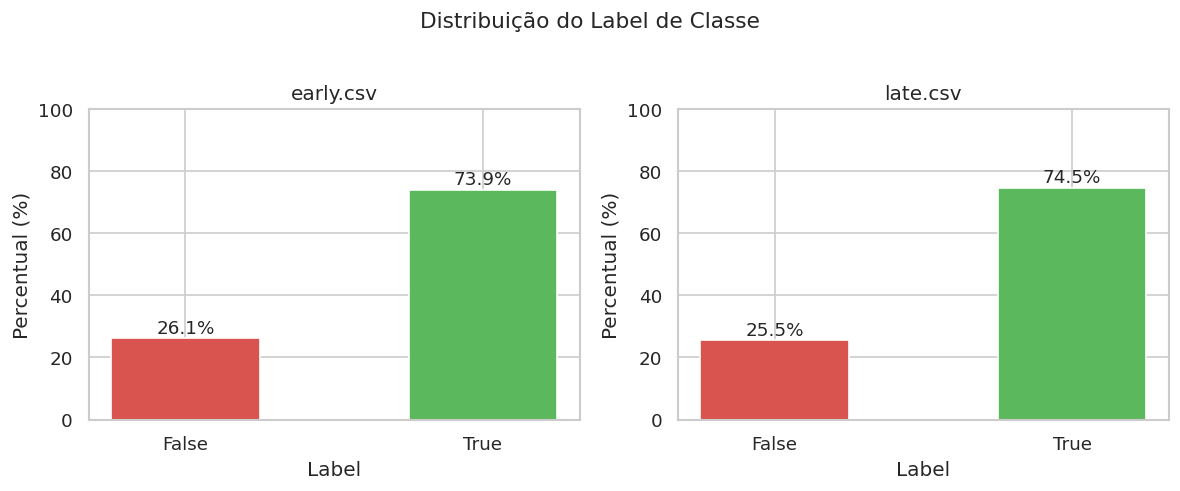

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (nome, df) in zip(axes, [('early.csv', early), ('late.csv', late)]):
    counts = df['Label'].value_counts(normalize=True).mul(100).sort_index()
    bars = ax.bar(
        counts.index.astype(str),
        counts.values,
        color=['#d9534f', '#5cb85c'],
        edgecolor='white',
        width=0.5
    )
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=11
        )
    ax.set_title(nome, fontsize=12)
    ax.set_xlabel('Label')
    ax.set_ylabel('Percentual (%)')
    ax.set_ylim(0, 100)

fig.suptitle('Distribuição do Label de Classe', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Achado:** Os arquivos de label mostram desbalanceamento moderado: `early.csv` tem 73.91% True / 26.09% False (14.317 registros) e `late.csv` tem 74.52% True / 25.48% False (9.386 registros). A taxa ~74% de sucesso (Label=True) refere-se à conclusão do assignment — é distinta da taxa de tentativas corretas individuais (~23.7% no split Release), que é a variável-alvo dos modelos de KT.
**Implicação para modelagem:** O desbalanceamento (~26% False) tornaria a acurácia enganosa (baseline trivial ≈ 74% ao prever sempre True). AUC-ROC é a métrica primária por ser threshold-independent e diretamente comparável com Shi et al. (2022). O split All (Fall 2019) é usado apenas para EDA; a avaliação final usa exclusivamente Release.

## 4. Métricas de Avaliação

O dataset é desbalanceado: aproximadamente 23.7% dos registros possuem `Label = True`. Em cenários desbalanceados, a acurácia simples é uma métrica enganosa (um classificador trivial que sempre prediz `False` atingiria ~76% de acurácia).

Por isso, a métrica primária adotada é a **AUC-ROC** (Area Under the ROC Curve):
- Independente do limiar de decisão
- Padrão na literatura de KT (Piech et al., 2015; Shi et al., 2022)
- Permite comparação direta com os resultados reportados nos papers

Métricas secundárias para análise complementar: Precision, Recall, F1-score.

## 5. Pergunta de Pesquisa

> KCs gerados de forma automática via análise de AST (srcML) + inferência de LLM melhoram a capacidade preditiva (AUC) dos modelos de Knowledge Tracing em relação ao baseline KC = AssignmentID?

## Resumo das Decisões

| Parâmetro | Valor adotado |
|---|---|
| KC baseline | `AssignmentID` (5 KCs: 439, 487, 492, 494, 502) |
| KC gerado | Fine-grained via srcML + LLM (notebook 03b) |
| Labels-alvo | `early.csv` / `late.csv`, coluna `Label` |
| Splits para avaliação | `Release/Train` e `Release/Test` |
| Métrica primária | AUC-ROC |
| Métricas secundárias | Precision, Recall, F1 |
| Seed fixo | 42 |
| Truncamento de sequências | Últimas 50 tentativas por estudante por KC |
| Threshold de acerto | `Score == 1.0` para `Run.Program` |